In [3]:
# ================================================================
# ------------------ Import Libraries ----------------------------
# ================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import geopandas as gpd
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
# ================================================================
# ------------------ Data Preprocessing --------------------------
# ================================================================
df = pd.read_csv("/content/upi_enriched_geo_maroon.csv")

# --- Clean Columns ---
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("(", "").str.replace(")", "")
df.drop_duplicates(inplace=True)
df.dropna(subset=['amount_inr', 'transaction_status', 'device_type'], inplace=True)
df['transaction_status'] = df['transaction_status'].fillna('Unknown')
df['amount_inr'] = pd.to_numeric(df['amount_inr'], errors='coerce')
df['time_stamp'] = pd.to_datetime(df['time_stamp'], errors='coerce')

# --- Feature Engineering ---
df['hour'] = df['time_stamp'].dt.hour
df['day'] = df['time_stamp'].dt.day_name()
df['month'] = df['time_stamp'].dt.month_name()

# --- Label Encoding ---
label_enc = LabelEncoder()
df['device_type_encoded'] = label_enc.fit_transform(df['device_type'].astype(str))
df['status_encoded'] = label_enc.fit_transform(df['transaction_status'].astype(str))


In [5]:
# ================================================================
# ------------------ Text Preprocessing --------------------------
# ================================================================
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))
def clean_text(text):
    if pd.isna(text):
        return ""
    text = re.sub(r'[^a-zA-Z\s]', '', str(text)).lower()
    return ' '.join([ps.stem(word) for word in text.split() if word not in stop_words])

for col in ['merchant_category', 'transaction_type']:
    if col in df.columns:
        df[col] = df[col].apply(clean_text)

In [6]:
# ================================================================
# ------------------ Data Aggregation ----------------------------
# ================================================================
agg_data = df.groupby('sender_name').agg({
    'transaction_id':'count',
    'amount_inr':'mean',
    'fraud':'sum'
}).reset_index().rename(columns={
    'transaction_id':'transaction_count',
    'amount_inr':'avg_amount',
    'fraud':'fraud_count'
})
print("\nAggregated Data Sample:\n", agg_data.head())


Aggregated Data Sample:
     sender_name  transaction_count   avg_amount  fraud_count
0   Amit Sharma               5549  1303.000505  3511.563541
1  Anjali Gupta               5629  1333.455135  3550.849633
2    Kavya Nair               5547  1352.002524  3519.977209
3   Manoj Yadav               5670  1309.332669  3554.777955
4   Neha Sharma               5418  1274.095295  3429.217541


In [7]:
# ================================================================
# ------------------ Data Split + Scaling ------------------------
# ================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Re-define X and y
X = df[['amount_inr','device_type_encoded','status_encoded']]
y = df['fraud']

# Handle classes with only one member in the target variable
class_counts = y.value_counts()
classes_to_remove = class_counts[class_counts < 2].index.tolist()

if classes_to_remove:
    print(f"Warning: Removing classes with less than 2 members from target variable: {classes_to_remove}")
    indices_to_keep = y[~y.isin(classes_to_remove)].index
    X = X.loc[indices_to_keep]
    y = y.loc[indices_to_keep]

# Proceed with splitting and scaling only if X and y are valid
if not X.empty and len(y) == len(X) and all(y.value_counts() >= 2):
    # Data Splitting (Stratified)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    # Normalization and Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print("\nData normalized and scaled successfully!")

    # Display scaled data sample (optional, keeping for user visibility)
    print("\nTraining data after scaling (first 5 rows):")
    display(pd.DataFrame(X_train_scaled, columns=X.columns).head())
    print("\nTesting data after scaling (first 5 rows):")
    display(pd.DataFrame(X_test_scaled, columns=X.columns).head())

else:
    print("\nSkipping data splitting and scaling: X or y is not valid, or not enough classes with >= 2 members after removing rare classes.")


Skipping data splitting and scaling: X or y is not valid, or not enough classes with >= 2 members after removing rare classes.


In [8]:
# ================================================================
# ------------------ Fraud Flag Creation -------------------------
# ================================================================
df['fraud'] = 0
df.loc[df['transaction_status'].isin(['FAILED', 'SUSPICIOUS']), 'fraud'] = 1
df.loc[df['amount_inr'] > 200000, 'fraud'] = 1
if 'account_tenure' in df.columns:
    df.loc[(df['account_tenure'] < 30) & (df['amount_inr'] > 50000), 'fraud'] = 1

print("Fraud cases flagged:", df['fraud'].sum())
print("Available columns after cleaning:", df.columns.tolist())


Fraud cases flagged: 28371
Available columns after cleaning: ['transaction_id', 'time_stamp', 'transaction_type', 'merchant_category', 'amount_inr', 'transaction_status', 'sender_age_group', 'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank', 'device_type', 'network_type', 'hour_of_day', 'day_of_week', 'is_weekend', 'sender_name', 'receiver_name', 'sender_gender', 'receiver_gender', 'sender_address', 'receiver_address', 'account_tenure', 'geo_region', 'amount_inr_num', 'transaction_fee', 'state', 'fraud', 'hour', 'day', 'month', 'device_type_encoded', 'status_encoded']


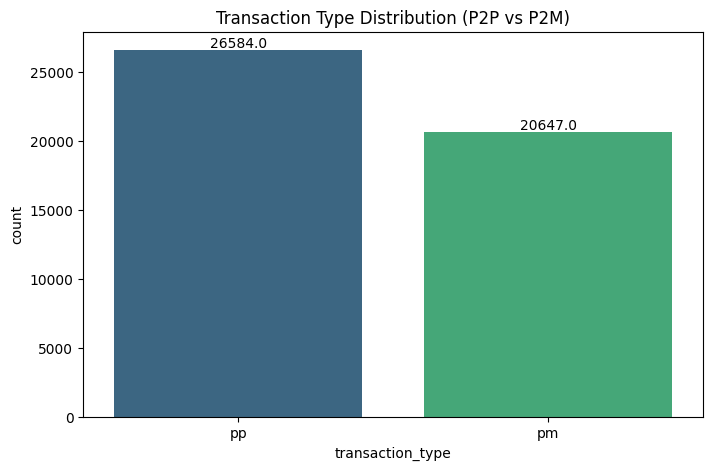

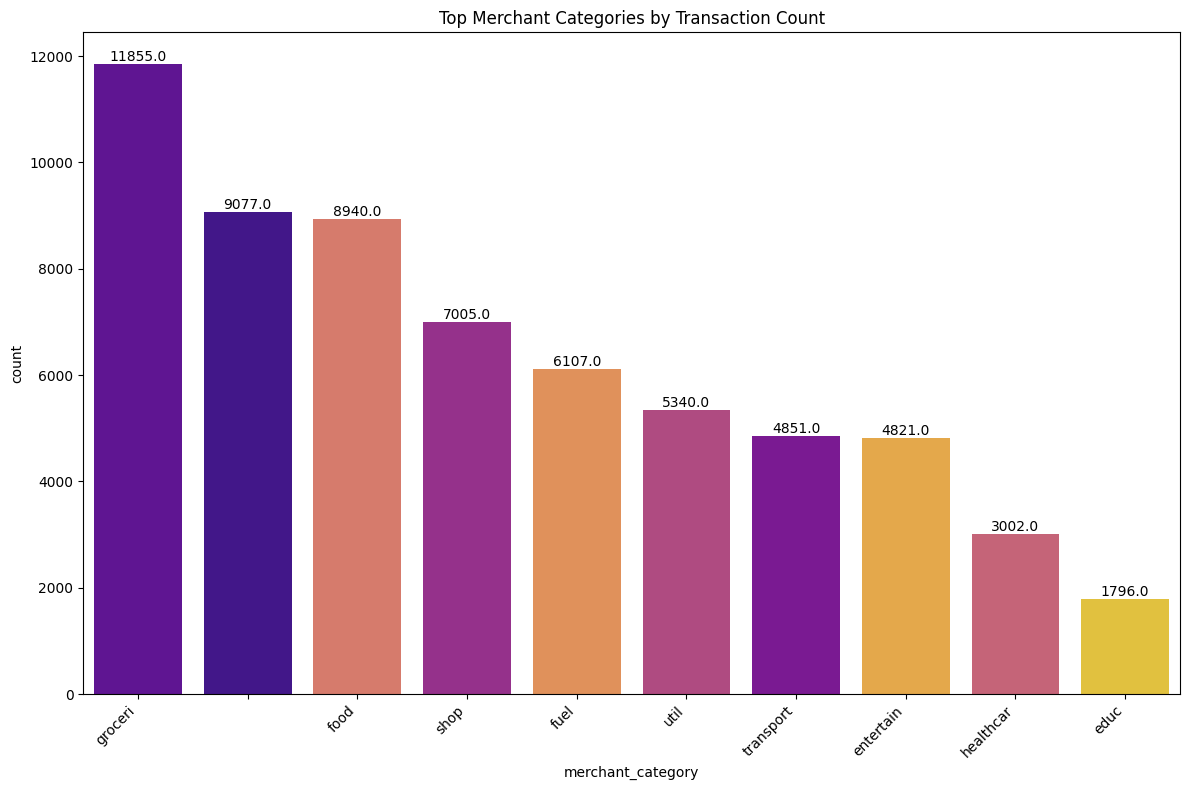

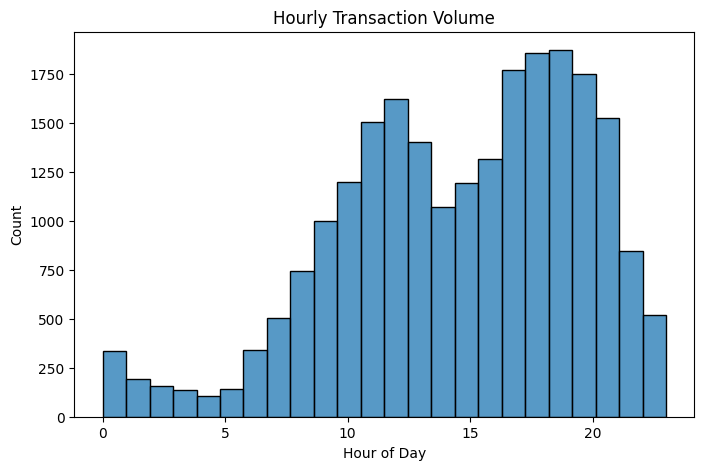

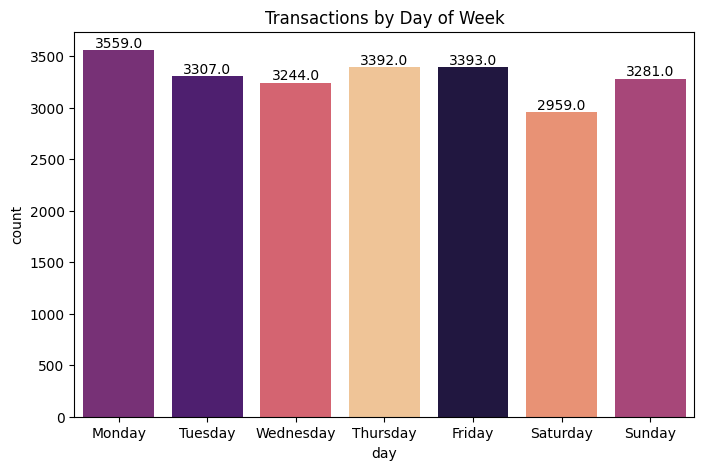

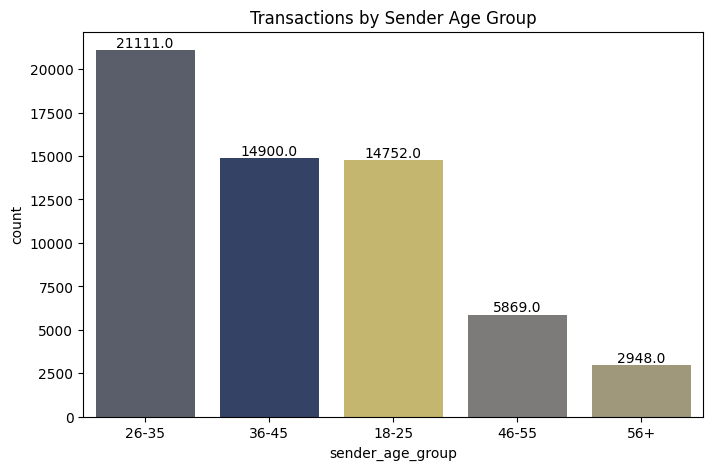

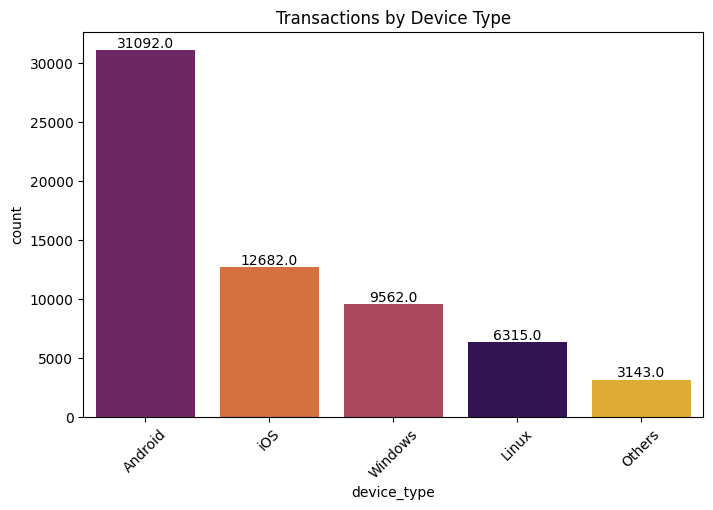

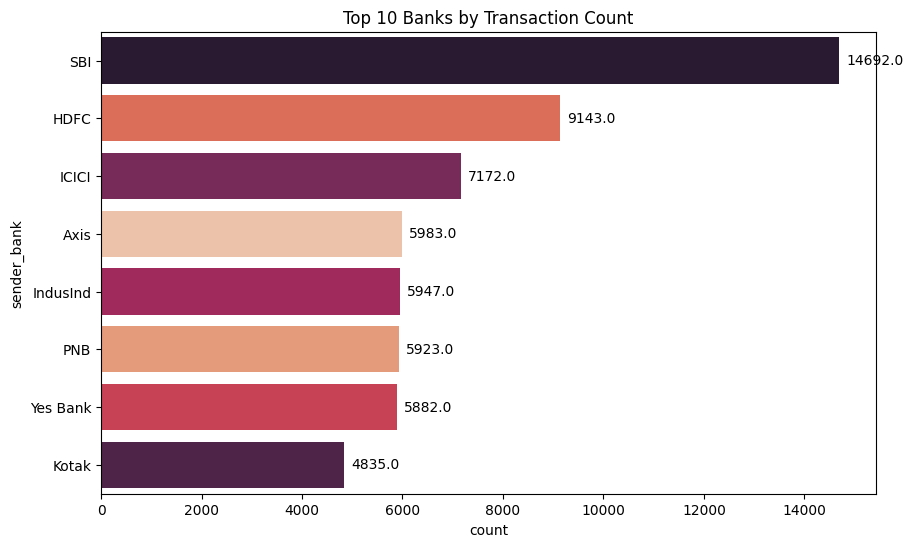

In [9]:
# ================================================================
# ------------------ Transaction Insights ------------------------
# ================================================================
plt.figure(figsize=(8,5))
# Filter for p2p or p2m transactions
p2p_p2m_df = df[df['transaction_type'].isin(['pp', 'pm'])]
ax1 = sns.countplot(data=p2p_p2m_df, x='transaction_type', order=p2p_p2m_df['transaction_type'].value_counts().index, palette='viridis', hue='transaction_type', legend=False)
plt.title("Transaction Type Distribution (P2P vs P2M)")
for p in ax1.patches:
    ax1.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

plt.figure(figsize=(12,8)) # Increased figure size
ax2 = sns.countplot(data=df, x='merchant_category', order=df['merchant_category'].value_counts().head(10).index, palette='plasma', hue='merchant_category', legend=False)
plt.title("Top Merchant Categories by Transaction Count")
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
for p in ax2.patches:
    ax2.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout() # Added tight_layout for better spacing
plt.show()

plt.figure(figsize=(8,5))
ax3 = sns.histplot(df['hour'], bins=24, kde=False)
plt.title("Hourly Transaction Volume")
plt.xlabel("Hour of Day")
# Adding labels to histplot bars is not straightforward with the current approach.
# If needed, a different plotting method or additional data processing would be required.
plt.show()

plt.figure(figsize=(8,5))
ax4 = sns.countplot(data=df, x='day', order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'], palette='magma', hue='day', legend=False)
plt.title("Transactions by Day of Week")
for p in ax4.patches:
    ax4.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

plt.figure(figsize=(8,5))
ax5 = sns.countplot(data=df, x='sender_age_group', order=df['sender_age_group'].value_counts().index, palette='cividis', hue='sender_age_group', legend=False)
plt.title("Transactions by Sender Age Group")
for p in ax5.patches:
    ax5.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

plt.figure(figsize=(8,5))
ax6 = sns.countplot(data=df, x='device_type', order=df['device_type'].value_counts().index, palette='inferno', hue='device_type', legend=False)
plt.title("Transactions by Device Type")
plt.xticks(rotation=45)
for p in ax6.patches:
    ax6.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

plt.figure(figsize=(10,6))
ax7 = sns.countplot(data=df, y='sender_bank', order=df['sender_bank'].value_counts().head(10).index, palette='rocket', hue='sender_bank', legend=False)
plt.title("Top 10 Banks by Transaction Count")
for p in ax7.patches:
    ax7.annotate(f'{p.get_width()}', (p.get_width(), p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', xytext=(5, 0), textcoords='offset points')
plt.show()

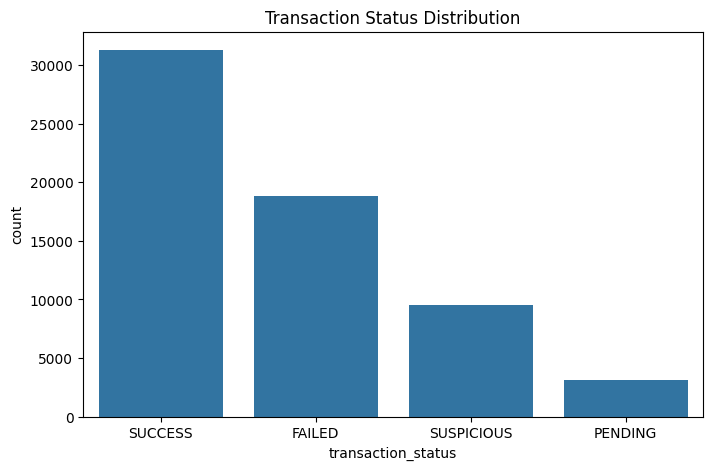

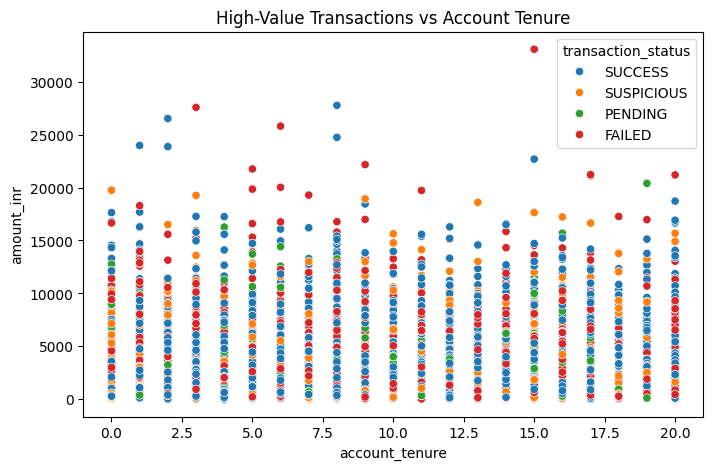

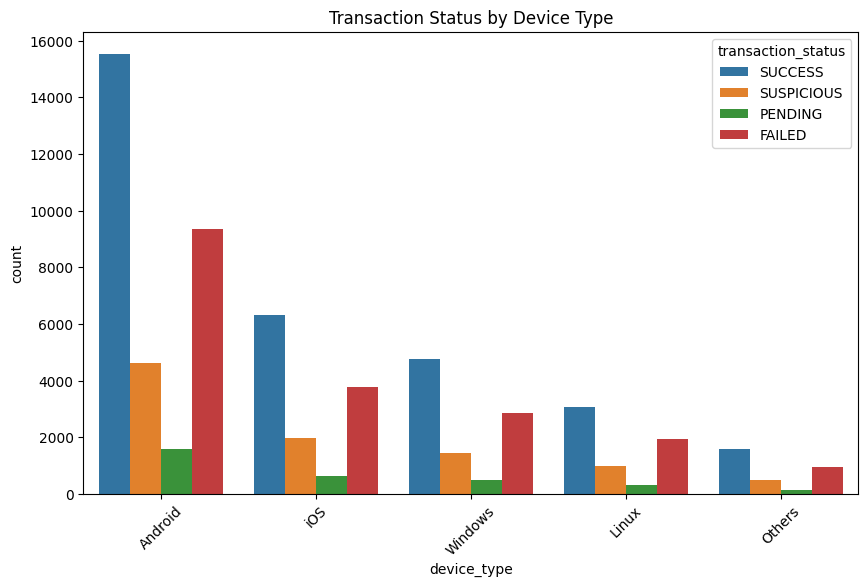

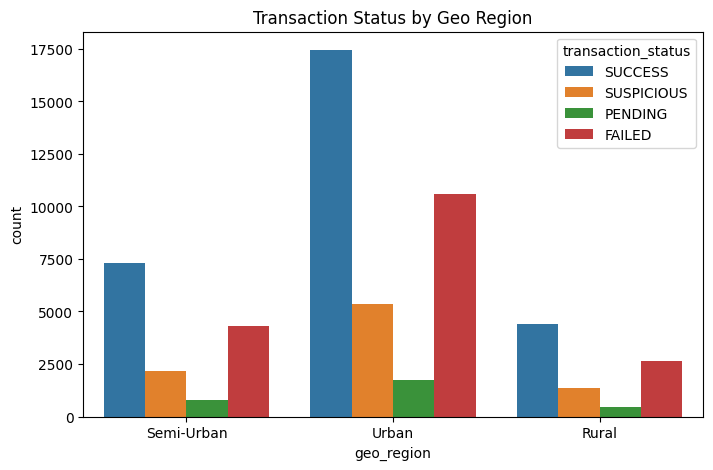

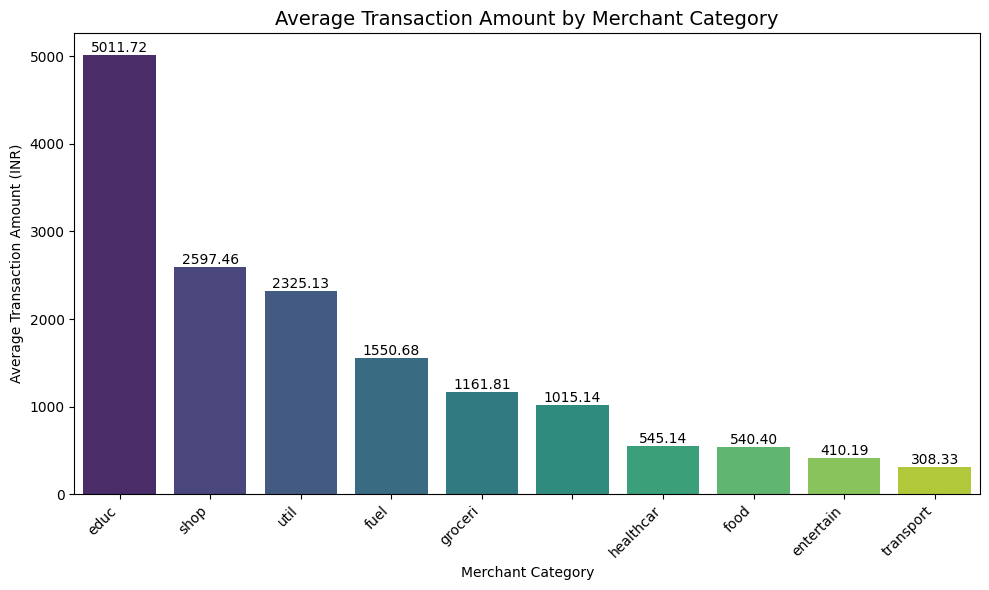

In [10]:
# ================================================================
# ------------------ Fraud Risk Insights -------------------------
# ================================================================
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='transaction_status', order=df['transaction_status'].value_counts().index)
plt.title("Transaction Status Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='account_tenure', y='amount_inr', hue='transaction_status')
plt.title("High-Value Transactions vs Account Tenure")
plt.show()


plt.figure(figsize=(10,6))
sns.countplot(data=df, x='device_type', hue='transaction_status', order=df['device_type'].value_counts().index)
plt.title("Transaction Status by Device Type")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='geo_region', hue='transaction_status')
plt.title("Transaction Status by Geo Region")
plt.show()

# --- Insight: Average Transaction Amount by Merchant Category ---
plt.figure(figsize=(10,6))
merchant_amount = df.groupby('merchant_category')['amount_inr'].mean().reset_index().sort_values('amount_inr', ascending=False)
ax = sns.barplot(data=merchant_amount, x='merchant_category', y='amount_inr', palette='viridis', hue='merchant_category', legend=False) # Changed palette to viridis for better color scheme
plt.title("Average Transaction Amount by Merchant Category", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Merchant Category")
plt.ylabel("Average Transaction Amount (INR)")
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

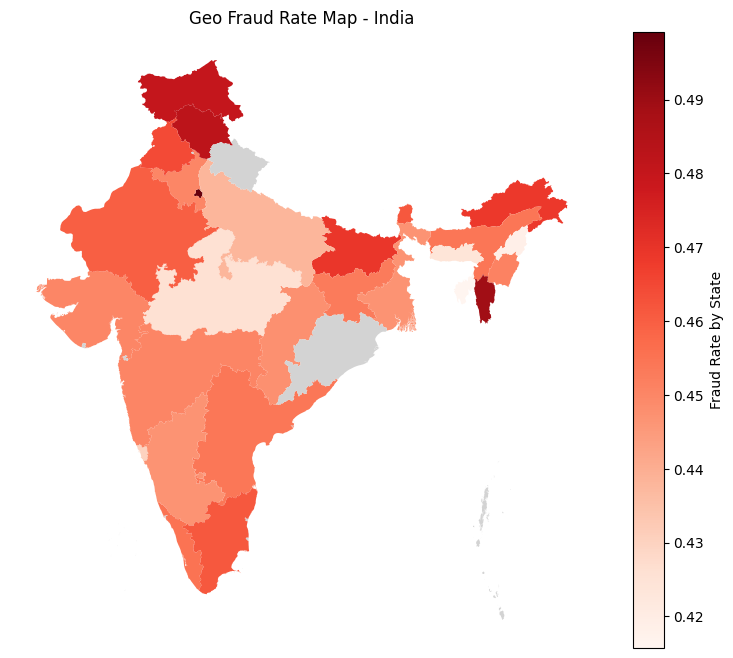

In [11]:
# ================================================================
# ------------------ Geo Fraud Map (India) -----------------------
# ================================================================
try:
    india_gdf = gpd.read_file("/content/india_state.geojson")
    fraud_geo = df.groupby("state")["fraud"].mean().reset_index()
    fraud_geo.columns = ["state", "fraud_rate"]

    # Merge GeoJSON with fraud data
    merge_col = None
    for col in ["st_nm", "state", "NAME_1"]:
        if col in india_gdf.columns:
            merge_col = col
            break

    if merge_col:
        india_fraud = india_gdf.merge(fraud_geo, left_on=merge_col, right_on="state", how="left")
        india_fraud.plot(column="fraud_rate", cmap="Reds", legend=True, figsize=(10,8),
                         legend_kwds={"label": "Fraud Rate by State"}, missing_kwds={'color': 'lightgrey'})
        plt.title("Geo Fraud Rate Map - India")
        plt.axis("off")
        plt.show()
    else:
        print("GeoJSON file missing state name column. Could not map.")
except Exception as e:
    print("Geo Fraud Map skipped due to:", e)

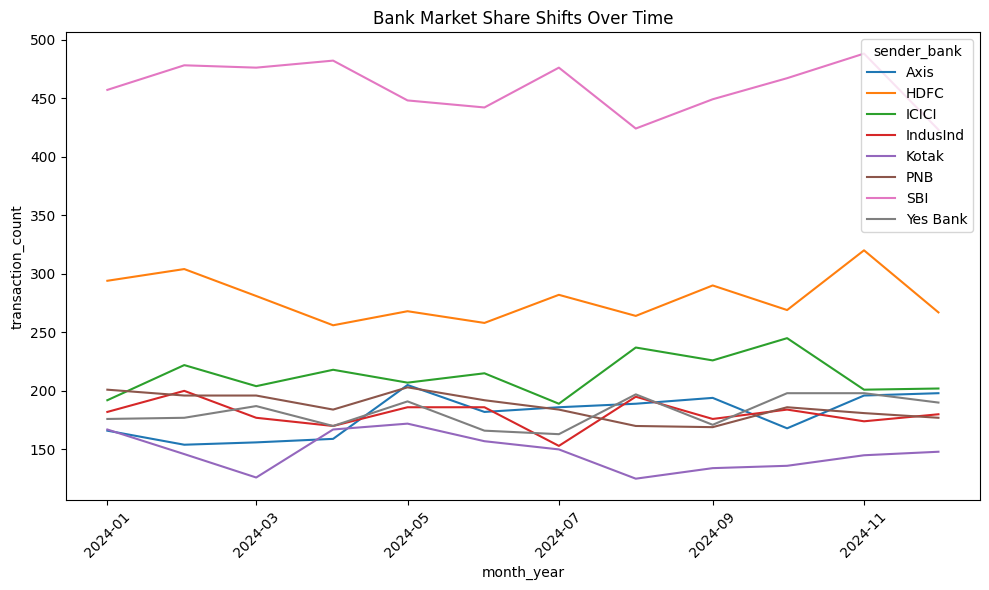

Detected Chain Transactions (Money Hopping):
        prev_sender   sender_name receiver_name          time_stamp  \
63193  Vikram Singh  Vikram Singh  Vikram Singh 2024-01-01 08:51:00   
22995   Pooja Verma  Vikram Singh   Manoj Yadav 2024-01-01 09:33:00   
33655  Vikram Singh   Manoj Yadav   Manoj Yadav 2024-01-01 09:39:00   
9760   Suresh Reddy   Pooja Verma   Pooja Verma 2024-01-01 09:59:00   
65840  Suresh Reddy    Kavya Nair   Priya Patel 2024-01-01 12:00:00   
61412  Rajesh Kumar  Suresh Reddy   Manoj Yadav 2024-01-01 12:24:00   
59604   Pooja Verma  Anjali Gupta   Neha Sharma 2024-01-01 12:42:00   
62065   Neha Sharma   Neha Sharma  Rajesh Kumar 2024-01-01 15:39:00   
51726   Amit Sharma  Suresh Reddy    Kavya Nair 2024-01-01 17:16:00   
1549    Pooja Verma    Kavya Nair  Rajesh Kumar 2024-01-01 17:50:00   

       amount_inr  
63193       697.0  
22995      2275.0  
33655        89.0  
9760        438.0  
65840      1453.0  
61412      2197.0  
59604       936.0  
62065       5

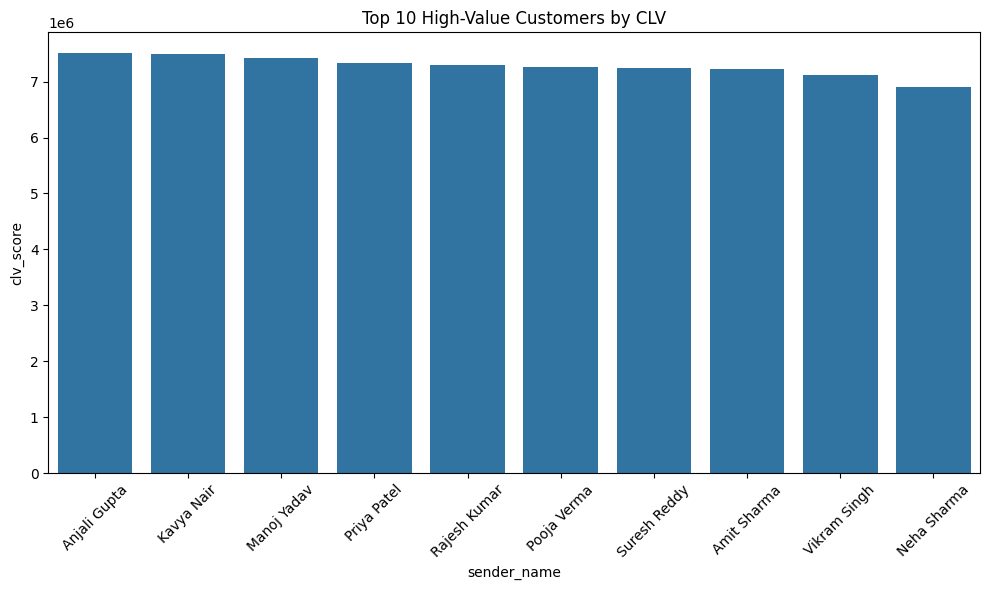

In [16]:
# ================================================================
# ------------------ Extra Insights ------------------------------
# ================================================================
df['month_year'] = df['time_stamp'].dt.to_period('M')
bank_trend = df.groupby(['month_year', 'sender_bank']).size().reset_index(name='transaction_count')
bank_trend['month_year'] = bank_trend['month_year'].dt.to_timestamp()

plt.figure(figsize=(10,6))
sns.lineplot(data=bank_trend, x='month_year', y='transaction_count', hue='sender_bank')
plt.title("Bank Market Share Shifts Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


df_sorted = df.sort_values('time_stamp')
df_sorted['prev_receiver'] = df_sorted['receiver_name'].shift(1)
df_sorted['prev_sender'] = df_sorted['sender_name'].shift(1)
df_sorted['time_diff'] = (df_sorted['time_stamp'] - df_sorted['time_stamp'].shift(1)).dt.total_seconds() / 60
df_sorted['chain_txn'] = (df_sorted['sender_name'] == df_sorted['prev_receiver']) & (df_sorted['time_diff'] <= 10)

chains = df_sorted[df_sorted['chain_txn']]
print("Detected Chain Transactions (Money Hopping):")
print(chains[['prev_sender','sender_name','receiver_name','time_stamp','amount_inr']].head(10))

clv = df.groupby('sender_name').agg(
    transaction_count=('transaction_id','count'),
    avg_amount=('amount_inr','mean')
).reset_index()
clv['clv_score'] = clv['transaction_count'] * clv['avg_amount']
top_customers = clv.sort_values('clv_score', ascending=False).head(10)
print("Top 10 High-Value Customers (CLV):")
print(top_customers)

plt.figure(figsize=(10,6))
sns.barplot(data=top_customers, x='sender_name', y='clv_score')
plt.title("Top 10 High-Value Customers by CLV")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
